# 03 - Time Trends & Operational KPI Dashboard

An analysis of delivery performance over time (Jan 2023 - Dec 2024), followed by an operational KPI dashboard broken down by hub and driver, built to flag where performance differences are meaningful versus where they're likely just noise.


## Setup


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/DianaLara/Downloads/Orders.csv', encoding='UTF-16', sep='\t')
df.head()


,Order ID,Actual Delivery Date,Delay Reason,Driver ID,Driver Name,Hub Name,Is Delayed,Is On Time,Order Date,Order Status,Vehicle Name,Vehicle Type,Customer Satisfaction Score,Delivery Time Hours,Hub Processing Time Hours
0,1,25-10-2024,NaN,43,Karen Rodriguez,San Antonio Hub,False,True,25-10-2024,Delivered,FT-036,Truck,4,6.81,0.89
1,2,16-06-2024,NaN,29,Matthew Williams,Houston Hub,False,True,16-06-2024,Delivered,FT-016,Van,4,5.74,3.60
2,3,05-07-2024,NaN,25,Nancy Harris,Austin Hub,False,True,05-07-2024,Delivered,FT-040,Van,4,12.91,2.07
3,4,22-08-2023,NaN,20,David Davis,Fort Worth Hub,False,True,22-08-2023,Delivered,FT-039,Van,5,9.40,2.37
4,5,06-06-2024,Severe Weather,49,Joseph Williams,Dallas Main Hub,True,False,02-06-2024,Delivered,FT-018,Truck,3,103.48,1.80


In [2]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')

In [5]:
df['Actual Delivery Date'] = pd.to_datetime(df['Actual Delivery Date'], dayfirst=True, errors='coerce')

df.head()

,Order ID,Actual Delivery Date,Delay Reason,Driver ID,Driver Name,Hub Name,Is Delayed,Is On Time,Order Date,Order Status,Vehicle Name,Vehicle Type,Customer Satisfaction Score,Delivery Time Hours,Hub Processing Time Hours,Order Month
0,1,2024-10-25,NaN,43,Karen Rodriguez,San Antonio Hub,False,True,2024-10-25,Delivered,FT-036,Truck,4,6.81,0.89,2024-10
1,2,2024-06-16,NaN,29,Matthew Williams,Houston Hub,False,True,2024-06-16,Delivered,FT-016,Van,4,5.74,3.60,2024-06
2,3,2024-07-05,NaN,25,Nancy Harris,Austin Hub,False,True,2024-07-05,Delivered,FT-040,Van,4,12.91,2.07,2024-07
3,4,2023-08-22,NaN,20,David Davis,Fort Worth Hub,False,True,2023-08-22,Delivered,FT-039,Van,5,9.40,2.37,2023-08
4,5,2024-06-06,Severe Weather,49,Joseph Williams,Dallas Main Hub,True,False,2024-06-02,Delivered,FT-018,Truck,3,103.48,1.80,2024-06


## 1. Monthly Time Trends

Tracking order volume, delivery speed, on-time rate, and satisfaction month-over-month to spot trends, seasonality, or shifts in performance.


In [6]:
df['Order Month'] = df['Order Date'].dt.to_period('M')

monthly_trends = pd.DataFrame({
    'total_orders': df.groupby('Order Month').size(),
    'avg_delivery_hours': df.groupby('Order Month')['Delivery Time Hours'].mean(),
    'on_time_pct': df.groupby('Order Month')['Is On Time'].mean() * 100,
    'avg_satisfaction': df.groupby('Order Month')['Customer Satisfaction Score'].mean()
})
print(monthly_trends.round(2).to_string())


             total_orders  avg_delivery_hours  on_time_pct  avg_satisfaction
Order Month                                                                 
2023-01              1124               35.96        78.20              4.16
2023-02              1036               35.52        80.31              4.20
2023-03              1221               36.65        77.48              4.18
2023-04              1191               35.67        79.01              4.18
2023-05              1233               35.64        78.99              4.18
2023-06              1177               35.35        81.14              4.21
2023-07              1151               36.74        78.89              4.16
2023-08              1178               35.78        79.03              4.16
2023-09              1067               34.75        80.04              4.17
2023-10              1233               34.71        80.05              4.20
2023-11              1195               35.49        78.24              4.19

<Axes: title={'center': 'Avg Delivery Time by Month'}, xlabel='Order Month'>

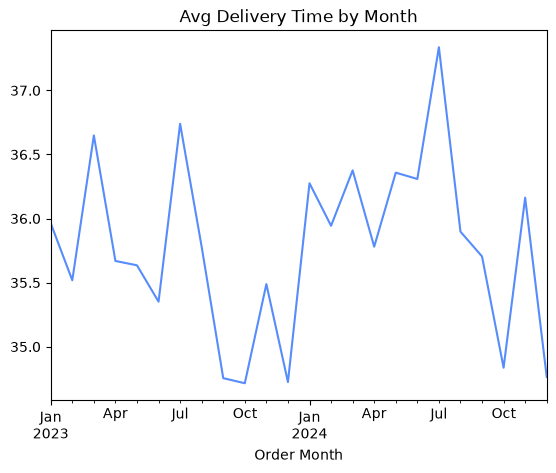

In [7]:
# Visualize the delivery time trend (requires matplotlib: !pip install matplotlib)
monthly_trends['avg_delivery_hours'].plot(title='Avg Delivery Time by Month')


**Finding:** across the full 24-month span (Jan 2023 - Dec 2024), performance is fairly stable overall, with a mild downward drift in 2024:

| Metric | 2023 avg | 2024 avg | Change |
|---|---|---|---|
| Avg delivery hours | 35.17 | 35.98 | +0.81 hrs (slower) |
| On-time % | 79.16% | 78.64% | -0.52 pts |
| Satisfaction | 4.18 | 4.16 | -0.02 |

The roughest stretch in the dataset is **May-July 2024**: avg delivery time peaks at 37.34 hrs (July), on-time rate bottoms out at 76.75-76.98% (May-June), and satisfaction dips to its lowest points (4.11-4.13). All three metrics degrading together in the same window reinforces the delivery-time/satisfaction relationship found in notebook 02.


## 2. Operational KPI Dashboard

A reusable function to generate a KPI summary table for any grouping column (hub, driver, vehicle type), combining volume, speed, on-time rate, satisfaction, and the two threshold rates identified as meaningful in notebook 02 (under 3 days / over 5 days).


In [8]:
def kpi_dashboard(df, group_col):
    """Build an operational KPI table for a given grouping column (Hub Name, Driver Name, etc.)"""
    kpi = df.groupby(group_col).agg(
        total_orders=('Order ID', 'count'),
        avg_delivery_hours=('Delivery Time Hours', 'mean'),
        on_time_pct=('Is On Time', lambda x: x.mean() * 100),
        avg_satisfaction=('Customer Satisfaction Score', 'mean'),
        pct_under_3_days=('Delivery Time Hours', lambda x: (x < 72).mean() * 100),
        pct_over_5_days=('Delivery Time Hours', lambda x: (x > 120).mean() * 100),
    )
    return kpi.round(2).sort_values('avg_satisfaction', ascending=False)


### 2.1 Hub-level KPIs


In [9]:
hub_kpis = kpi_dashboard(df, 'Hub Name')
print(hub_kpis)


                 total_orders  avg_delivery_hours  on_time_pct  \
Hub Name                                                         
El Paso Hub              2718               35.24        80.57   
Dallas Main Hub          7345               35.78        78.91   
Fort Worth Hub           3255               36.50        78.46   
Houston Hub              6875               35.79        79.08   
San Antonio Hub          3721               35.79        78.69   
Austin Hub               4065               35.53        77.88   

                 avg_satisfaction  pct_under_3_days  pct_over_5_days  
Hub Name                                                              
El Paso Hub                  4.19             93.82             0.48  
Dallas Main Hub              4.17             92.68             0.59  
Fort Worth Hub               4.17             92.63             0.58  
Houston Hub                  4.17             92.95             0.64  
San Antonio Hub              4.16            

**Finding — Austin Hub:** lowest-ranked hub overall, but *not* because of average delivery time (35.53 hrs, actually faster than 3 of the 5 other hubs). Instead, Austin has the highest `pct_over_5_days` (0.76%, the tail-risk "danger zone") and lowest `pct_under_3_days` (91.91%). This is a good example of why the average alone can hide a real pattern: Austin's issue is inconsistency at the extremes, not typical performance, and that tail risk is what appears to be dragging its satisfaction score down.

**Finding — Fort Worth Hub:** has the slowest *average* delivery time (36.50 hrs) despite handling the second-lowest order volume (3,255 orders), counter to the usual assumption that lower volume means less strain and faster service.


In [10]:
# Check whether Fort Worth's slow average is driven by outliers (high variability) or a consistent shift
df.groupby('Hub Name')['Delivery Time Hours'].agg(['mean', 'std', 'count']).round(2)


,mean,std,count
Hub Name,,,
Austin Hub,35.53,24.09,4021
Dallas Main Hub,35.78,23.93,7282
El Paso Hub,35.24,23.04,2697
Fort Worth Hub,36.50,24.28,3235
Houston Hub,35.79,23.79,6807
San Antonio Hub,35.79,23.74,3685


**Finding:** Fort Worth's standard deviation (24.28) is only marginally higher than the other hubs (range: 23.04-24.09), ruling out a few extreme outliers as the explanation. This means Fort Worth is *consistently* a bit slower across most deliveries, rather than being skewed by a handful of bad cases — though the actual gap (0.7-1.3 hours vs. other hubs) is modest. This is a lower-confidence finding than Austin's tail-risk pattern, and is called out as such rather than treated with equal weight.


### 2.2 Driver-level KPIs


In [12]:
driver_kpis = kpi_dashboard(df, 'Driver Name')
print("Top 15 drivers by satisfaction:")
print(driver_kpis.head(15))


Top 15 drivers by satisfaction:
                    total_orders  avg_delivery_hours  on_time_pct  \
Driver Name                                                         
Nancy Thompson               417               36.75        81.06   
Jessica Jones                424               34.14        79.95   
Charles Moore                464               34.95        82.33   
Elizabeth Jones              435               34.99        80.69   
Donald Jackson               412               35.14        81.07   
Christopher Davis            442               36.10        81.45   
Daniel Williams              384               34.21        79.95   
Kevin White                  399               34.20        80.20   
Thomas Martin                413               33.22        81.84   
Donald Anderson              413               35.07        81.11   
Charles Thompson            1531               36.17        78.84   
Joseph Williams              448               34.94        79.02   
Je

In [13]:
print("Bottom 15 drivers by satisfaction:")
print(driver_kpis.tail(15))


Bottom 15 drivers by satisfaction:
                   total_orders  avg_delivery_hours  on_time_pct  \
Driver Name                                                        
Lisa Moore                  417               37.45        74.34   
Matthew Williams            428               35.52        79.21   
Matthew Rodriguez           428               37.09        77.34   
Kevin Jones                 438               34.46        79.68   
Karen Rodriguez            1233               36.72        77.78   
Anthony Jackson             419               34.91        77.57   
Nancy Harris                377               35.90        76.66   
Patricia Jones              424               36.89        78.07   
Mary Harris                 446               36.90        78.25   
James Anderson              431               36.13        79.35   
Patricia Martinez           443               35.98        75.17   
Robert Garcia               435               35.30        78.39   
Sarah Moore  

**Findings:**

- **Overall spread is narrow:** best driver (4.24) vs. worst driver (4.07) is only a 0.17-point gap on a 5-point scale, the weakest signal found across this whole project. Worth stating plainly rather than forcing a dramatic narrative onto a small difference.
- **Karen Hernandez** has both the lowest satisfaction score (4.08) and the slowest average delivery time (37.78 hrs) of any driver in the dataset, the cleanest individual-level story, consistent with the delivery-time/satisfaction relationship found throughout this project.
- **Charles Thompson vs. Karen Rodriguez:** both are volume outliers (1,531 and 1,233 orders respectively, vs. ~400-450 for most drivers), but Charles Thompson holds up on quality (4.20 satisfaction, mid-pack) while Karen Rodriguez trends toward the bottom (4.14). High volume alone doesn't determine service quality.


### 2.3 Investigating the cause: delay reasons by driver

To check whether Karen Hernandez's slower performance has an identifiable root cause, her delay reason distribution was compared against Charles Thompson and Karen Rodriguez.


In [14]:
driver_delays = df[df['Driver Name'].isin(['Karen Hernandez', 'Charles Thompson', 'Karen Rodriguez'])]
print(driver_delays.groupby('Driver Name')['Delay Reason'].value_counts())


Driver Name       Delay Reason           
Charles Thompson  Vehicle Breakdown          38
                  Hub Processing Delay       36
                  Customer Not Home          36
                  Incorrect Address          32
                  Traffic Congestion         31
                  Road Construction          31
                  Severe Weather             31
                  Multiple Delivery Stops    31
                  Package Sorting Error      30
                  Driver Unavailable         28
Karen Hernandez   Traffic Congestion         13
                  Severe Weather             12
                  Multiple Delivery Stops    12
                  Road Construction          12
                  Customer Not Home          10
                  Driver Unavailable          9
                  Hub Processing Delay        8
                  Vehicle Breakdown           7
                  Incorrect Address           6
                  Package Sorting Error       

**Finding — no clear root cause identified:** normalizing for order volume, all three drivers have nearly identical overall delay rates (Karen Hernandez ~21.8%, Karen Rodriguez ~22.2%, Charles Thompson ~21.2%), and the *distribution* of delay reasons is proportionally similar across all three — no single category (e.g. Vehicle Breakdown, Traffic Congestion) disproportionately affects Karen Hernandez compared to the others.

This suggests her slower average is more likely due to normal variation (route assignments, geography, timing) than a specific, fixable operational issue. This is reported as a legitimate null result rather than forcing a conclusion as not every performance gap has a clean, identifiable cause.


## Summary of Key Findings

**Time Trends**
- Performance is broadly stable over 24 months, with a mild overall decline in 2024 vs. 2023 across delivery time, on-time rate, and satisfaction.
- May-July 2024 stands out as the weakest stretch across all three metrics simultaneously, a real-world instance of the delivery-time/satisfaction relationship identified in notebook 02.

**Hub KPIs**
- Austin Hub: weakest hub overall, driven by tail risk (highest rate of 5+ day deliveries) rather than a slow average (a pattern the average alone would have hidden).
- Fort Worth Hub: slowest average delivery time despite low volume; confirmed as a consistent (not outlier-driven) but modest effect via standard deviation (a lower-confidence finding than Austin's).

**Driver KPIs**
- Driver-level satisfaction differences are the weakest signal in the project (0.17-point spread top to bottom).
- Karen Hernandez stands out as the clearest individual case: slowest average delivery time and lowest satisfaction score, though a delay-reason investigation found no specific identifiable cause, which most likely indicates a normal variation rather than a fixable issue.
- High order volume does not inherently predict lower quality (Charles Thompson vs. Karen Rodriguez).

**Next steps:** investigate route/geography-level data if available, to test whether Karen Hernandez's routes differ systematically from her peers' in ways not captured by delay reason alone; consider a vehicle-type KPI breakdown using the same `kpi_dashboard()` function.
